# Lab 5: Adversarial Search — Minimax & Alpha-Beta

This notebook walks you through adversarial search step by step.
You will implement the algorithms, run experiments, and reflect on the results.

**No prior game-AI experience required.** Every concept is explained before you use it.

| Algorithm   | Key idea                              | Nodes explored        | Optimal? |
|-------------|---------------------------------------|-----------------------|----------|
| Minimax     | Explore the **full** game tree        | O(b^d) — every node   | Yes      |
| Alpha-Beta  | Skip branches that **cannot matter**  | O(b^(d/2)) best case  | Yes      |

> Both algorithms find the **same best move**. Alpha-Beta just gets there with far less work.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '../..'))
import fai_viz
print('fai_viz loaded')

fai_viz loaded


## The Tic-Tac-Toe Game Tree

Minimax backs up values from terminal nodes to find the best move at the root.

/Users/yiweizhang/Study/FAI/lab5_adversarial_search/fai_viz.py:518: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


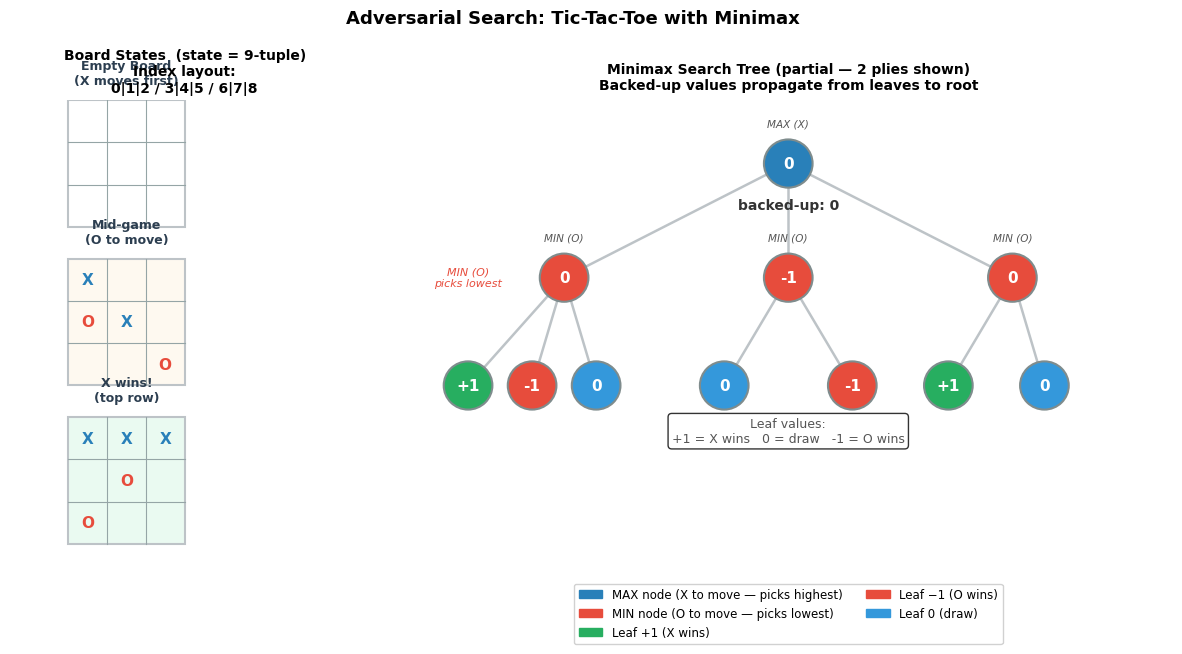

State representation: 9-tuple  ('X', 'O', or '.' for each cell)
Index layout:  0|1|2
               3|4|5
               6|7|8


In [2]:
fai_viz.show_tictactoe_minimax_figure()

## Setup — Run This Cell First

In [ ]:
# ── All helper functions are provided here — run this cell first ──────────────

# Board layout — tuple of 9 cells, left-to-right, top-to-bottom:
#   0 | 1 | 2
#   ---------
#   3 | 4 | 5
#   ---------
#   6 | 7 | 8

def make_game_state(board=None, to_move='X'):
    if board is None:
        board = ('.',) * 9
    return {'board': board, 'to_move': to_move}

def make_game_problem(board=None, to_move='X'):
    return {
        'initial': make_game_state(board, to_move),
        'winning_lines': [
            (0, 1, 2), (3, 4, 5), (6, 7, 8),   # rows
            (0, 3, 6), (1, 4, 7), (2, 5, 8),   # columns
            (0, 4, 8), (2, 4, 6),               # diagonals
        ]
    }

def print_board(state):
    board = state['board']
    for row in range(3):
        print(' | '.join(' {} '.format(board[row*3 + col]) for col in range(3)))
        if row < 2: print('-----------')
    print("To move: {}\n".format(state['to_move']))

def apply_move(state, position):
    board_copy = list(state['board'])
    board_copy[position] = state['to_move']
    next_player = 'O' if state['to_move'] == 'X' else 'X'
    return make_game_state(tuple(board_copy), next_player)

def get_actions(problem, state):
    """Return a list of (action, result_state) pairs for every legal move."""
    actions = []
    for position, cell in enumerate(state['board']): # enumerate() is a function that returns a tuple of the index and the value of the element in the list
        if cell == '.':
            next_state = apply_move(state, position)
            actions.append((position, next_state))
    return actions

def check_winner(problem, board):
    """Return 'X', 'O', or None."""
    for i, j, k in problem['winning_lines']:
        if board[i] == board[j] == board[k] != '.': # if the three elements in the tuple are the same and not '.'
            return board[i]
    return None

def is_terminal(problem, state): #return True if the game is over, False otherwise
    """True when the game is over (someone won or board is full)."""
    return check_winner(problem, state['board']) is not None or '.' not in state['board'] 

def utility(problem, state):
    """Outcome at a terminal state: +1 X wins, -1 O wins, 0 draw."""
    winner = check_winner(problem, state['board'])
    if winner == 'X': return +1
    if winner == 'O': return -1
    return 0

# ── Node counter helpers ──────────────────────────────────────────────────────
def mm_count(problem, state, is_maximizing, counter):
    """Minimax with a node counter — for measuring expansions."""
    counter[0] += 1
    if is_terminal(problem, state):
        return utility(problem, state), None
    
    if is_maximizing:
        best_value = float('-inf') # if the current player is MAX, then the best value is -infinity
    else:
        best_value = float('inf') # if the current player is MIN, then the best value is infinity

    best_move = None
    for move, next_state in get_actions(problem, state):
        value, _ = mm_count(problem, next_state, not is_maximizing, counter)
        if is_maximizing and value > best_value: # if the current player is MAX, then the best value is the maximum value of the next state
            best_value, best_move = value, move
        if not is_maximizing and value < best_value: # if the current player is MIN, then the best value is the minimum value of the next state 
            best_value, best_move = value, move
    return best_value, best_move

def ab_count(problem, state, alpha, beta, is_maximizing, counter):
    """Alpha-Beta with a node counter — for measuring expansions."""
    counter[0] += 1
    if is_terminal(problem, state):
        return utility(problem, state), None
    
    if is_maximizing:
        best_value = float('-inf')
    else:
        best_value = float('inf')

    best_move = None
    for move, next_state in get_actions(problem, state):
        value, _ = ab_count(problem, next_state, alpha, beta, not is_maximizing, counter)
        if is_maximizing and value > best_value:
            best_value, best_move = value, move
            alpha = max(alpha, best_value)
            if best_value >= beta: break # beta-cutoff
        if not is_maximizing and value < best_value:
            best_value, best_move = value, move
            beta = min(beta, best_value)
            if best_value <= alpha: break # alpha-cutoff
    return best_value, best_move

print('All helpers loaded. Ready for adversarial search!')

## Part 1: Adversarial Search vs. Single-Agent Search

In Labs 2–4 you solved problems where **one agent** looked for a path.
Now there are **two agents** — and the opponent actively tries to beat you.

| Component       | Labs 2–4 (single-agent)              | Lab 5 (adversarial)                        |
|-----------------|--------------------------------------|--------------------------------------------|
| Problem dict    | `{'initial': s, 'goal': g, ...}`     | `{'initial': s, 'winning_lines': [...]}`   |
| Terminal test   | `is_goal(problem, state)`            | `is_terminal(problem, state)`              |
| Actions         | `get_actions(problem, state)`        | `get_actions(problem, state)`              |
| Outcome / cost  | path cost `g(n)`                     | `utility(state)` → +1 / 0 / −1            |

### MAX and MIN
- **MAX (X)** picks the move with the **highest** utility — X wants to win (+1).
- **MIN (O)** picks the move with the **lowest** utility — O wants to win (−1).

### Minimax — sort the game tree by what each player would rationally choose
```
minimax(problem, state, is_maximizing):
    if is_terminal(problem, state): return utility(problem, state)
    if MAX: return max over (move, next) in get_actions(...)
                of minimax(problem, next, False)
    if MIN: return min over (move, next) in get_actions(...)
                of minimax(problem, next, True)
```

### Alpha-Beta — same answer, fewer nodes
Track two bounds while searching:
- **alpha**: the best value MAX can already guarantee (starts at −∞)
- **beta**:  the best value MIN can already guarantee (starts at +∞)

| Cutoff          | Fires at | Condition         | Meaning                                |
|-----------------|----------|-------------------|----------------------------------------|
| **beta-cutoff** | MAX node | `value >= beta`   | MIN already has a better move above    |
| **alpha-cutoff**| MIN node | `value <= alpha`  | MAX already has a better move above    |

## Part 2: Worked Example — Empty Board

Let's run Minimax and Alpha-Beta from the very start of a game, before writing any code yourself.

In [ ]:
# Worked example — run both algorithms from the empty board
p = make_game_problem()
is_maximizing = True

mm_c, ab_c = [0], [0]
mm_val, mm_move = mm_count(p, p['initial'], is_maximizing, mm_c)
ab_val, ab_move = ab_count(p, p['initial'], -float('inf'), float('inf'), is_maximizing, ab_c)

# .format() quick reference:
#   "{}".format(x)      → insert x as-is
#   "{:+d}".format(x)   → always show sign (+/-) then integer, e.g. +0 or -1
#   "{:,}".format(x)    → add thousands commas, e.g. 362880 → 362,880
#   "{:.1f}".format(x)  → float with 1 decimal place, e.g. 3.0
print("Minimax  :  best move = {},  value = {:+d},  nodes expanded = {:,}".format(mm_move, mm_val, mm_c[0]))
print("AlphaBeta:  best move = {},  value = {:+d},  nodes expanded = {:,}".format(ab_move, ab_val, ab_c[0]))
print("Speedup  :  {:.1f}x fewer nodes with Alpha-Beta".format(mm_c[0] / ab_c[0]))
print()
print("Notice:")
print("  - Both find the same best move and the same value (+0 = forced draw with perfect play).")
print("  - Alpha-Beta explores far fewer nodes — it prunes branches that cannot change the result.")
print("  - The center (position 4) is a top choice because it is involved in the most winning lines.")

---
## Demo: Two Minimax Agents Play Each Other

Now let's watch a complete game where **both X and O use Minimax** to choose every move.

| Player | Role | Goal |
|--------|------|------|
| X | MAX | pick the move with the **highest** utility (+1 = X wins) |
| O | MIN | pick the move with the **lowest** utility  (−1 = O wins) |

Because both agents play **perfectly**, neither side can force a win — the game always ends in a **draw**.
This is how we know Tic-Tac-Toe is a *solved* game: optimal play from both sides guarantees a draw.

Notice how the number of nodes searched **drops each turn** — as the board fills up, there are fewer remaining moves to explore.

In [ ]:
# ── Demo: Two Minimax Agents Play Each Other ─────────────────────────────────
#
# Both X and O use Minimax to decide every move.
# Each turn:
#   1. The current player calls mm_count() to find the best move.
#   2. We apply that move and print the updated board.
#   3. We also show how many nodes Minimax had to search this turn.
#
# Because both agents play perfectly, the game always ends in a draw.

def play_game_minimax(problem):
    """Let two Minimax agents play a full game, printing every move."""
    state = problem['initial']   # start from an empty board
    total_nodes = [0]            # running total of nodes expanded across all turns
    move_number = 0

    print("=== Two Minimax Agents Play Tic-Tac-Toe ===\n")
    print("Starting board:")
    print_board(state)

    while not is_terminal(problem, state):
        move_number += 1
        player = state['to_move']            # 'X' or 'O'
        is_maximizing = (player == 'X')      # X is MAX (+1), O is MIN (-1)

        # Ask Minimax: "what is the best move from this position?"
        counter = [0]                        # reset node counter for this turn
        value, best_move = mm_count(problem, state, is_maximizing, counter)
        total_nodes[0] += counter[0]

        # Apply the chosen move to get the new board
        state = apply_move(state, best_move) # replace the current state with the new state after applying the best move, the to_move in the new state will be the opponent's turn

        print("Move {}: {} plays position {}  (expected outcome: {:+d},  nodes this turn: {:,})".format(
            move_number, player, best_move, value, counter[0]))
        print_board(state)

    # Game is over — print the final result
    winner = check_winner(problem, state['board'])
    print("=" * 55)
    if winner:
        print("Result: {} wins!".format(winner))
    else:
        print("Result: Draw — both agents played perfectly, so neither side can win.")
    print("Total nodes expanded across all {} moves: {:,}".format(move_number, total_nodes[0]))

# Run the demo!
p = make_game_problem()
play_game_minimax(p)

## Part 3: Exercises

Work through each exercise in order. Each one builds on the previous.

---
## Exercise 1 — Explore Terminal States

**Goal:** understand `is_terminal` and `utility` before implementing the algorithms.

Run the cell below. For each board state it will print:
- whether the game is over
- and, if so, what the outcome (+1 / 0 / −1) is

In [ ]:
# ── Exercise 1 ────────────────────────────────────────────────────────────────
# These board states are already defined for you — just run this cell.
p = make_game_problem()

test_states = [
    ('X wins (row)',   make_game_state(('X','X','X','O','O','.','.','.','.'),'O')),
    ('O wins (diag)',  make_game_state(('X','X','O','X','O','.','O','.','.'),'X')),
    ('Draw',           make_game_state(('X','O','X','O','X','O','O','X','O'),'X')),
    ('Mid-game',       make_game_state(('X','O','.','.','X','.','.','.','.') ,'O')),
]

# {:20s} → pad the string to a 20-character-wide column (spaces fill the right side)
print("{:20s}  {:10s}  {:8s}  Board".format('Label', 'Terminal?', 'Utility'))
print('-' * 65)
for label, state in test_states:
    terminal = is_terminal(p, state)
    val      = utility(p, state) if terminal else 'n/a' # utility is only defined for terminal states, so we show 'n/a' for non-terminal states
    board_str = ''.join(state['board']) #.''.join() takes a list of strings and concatenates them into a single string, e.g. ['X', 'O', '.'] → 'XO.'
    print("{:20s}  {:10s}  {:8s}  {}".format(label, str(terminal), str(val), board_str))
print()
# Reflection — answer in comments:
# Q1: What utility does X winning always produce?   →
# Q2: What utility does O winning always produce?   →
# Q3: Is a mid-game state terminal?                 →

---
## Exercise 2 — Implement Minimax

**Goal:** fill in the three blanks in the `minimax` skeleton below.

```
minimax(problem, state, is_maximizing):
    if terminal → return utility
    if MAX: start from −∞, keep updating when value > best_value
    if MIN: start from +∞, keep updating when value < best_value
```

The structure mirrors Lab 4's `general_search`: a fixed outer loop, and **you** decide the key comparison.

In [ ]:
# ── Exercise 2 ────────────────────────────────────────────────────────────────
def minimax(problem, state, is_maximizing):
    """Return (best_value, best_move)."""

    # Base case — game is over
    if is_terminal(problem, state):
        return utility(problem, state), None   # ← already provided

    if is_maximizing:
        best_value = # YOUR CODE: X starts at the worst possible value for MAX 
    else:
        best_value = # YOUR CODE: O starts at the worst possible value for MIN 
    best_move = None

    for move, next_state in get_actions(problem, state):
        value, _ = minimax(problem, next_state, not is_maximizing)

        if is_maximizing and value > best_value:      # X found a better move
            best_value, best_move = value, move

        if not is_maximizing and # YOUR CODE: fill in the condition for O finding a better move  
            best_value, best_move = value, move

    return best_value, best_move

# ── Test your implementation ──
p = make_game_problem()
v, move = minimax(p, p['initial'], is_maximizing=True)
# {:+d} → always show the sign (+ or -), e.g. +0 or -1
print('Minimax — best opening move for X: position {},  value = {:+d}'.format(move, v))
print('Expected: value = +0  (perfect play always draws in Tic-Tac-Toe)')

# Near-win board: X is one move from winning
near_win = make_game_state(('X','X','.','O','O','.','.','.','.'), 'X')
v2, move2 = minimax(p, near_win, is_maximizing=True)
print('Near-win for X: best move = {},  value = {:+d}'.format(move2, v2))
print('Expected: position 2  (completes the top row → value = +1)')

---
## Exercise 3 — Add Alpha-Beta Pruning

**Goal:** extend minimax with two pruning conditions so that branches that
cannot change the result are skipped.

The skeleton below is identical to `minimax` **plus** two extra variables
(`alpha` and `beta`) and **four lines** you need to fill in.

| What to fill in                          | Where          |
|------------------------------------------|----------------|
| Update `alpha` after MAX finds a move    | MAX block      |
| Beta-cutoff: stop if `best_value >= beta`| MAX block      |
| Update `beta` after MIN finds a move     | MIN block      |
| Alpha-cutoff: stop if `best_value <= alpha` | MIN block   |

In [ ]:
# ── Exercise 3 ────────────────────────────────────────────────────────────────
def alphabeta(problem, state, alpha, beta, is_maximizing):
    """Same result as minimax — prunes branches using alpha and beta bounds."""

    if is_terminal(problem, state):
        return utility(problem, state), None

    best_value = -float('inf') if is_maximizing else +float('inf')
    best_move = None

    for move, next_state in get_actions(problem, state):
        value, _ = alphabeta(problem, next_state, alpha, beta, not is_maximizing)

        if is_maximizing and value > best_value:
            best_value, best_move = value, move
            alpha = # YOUR CODE: update alpha  
            if best_value >= beta:              # beta-cutoff
                break                           # ← already provided

        if not is_maximizing and value < best_value:
            best_value, best_move = value, move
            beta = # YOUR CODE: update beta 
            if # YOUR CODE: alpha-cutoff condition  
                break

    return best_value, best_move

# ── Test: same move as minimax? ──
p = make_game_problem()
mm_val,  mm_move  = minimax(p, p['initial'], True)
ab_val,  ab_move  = alphabeta(p, p['initial'], -float('inf'), float('inf'), True)

print('Minimax  : move={}, value={:+d}'.format(mm_move, mm_val))
print('AlphaBeta: move={}, value={:+d}'.format(ab_move, ab_val))

print('Same move? {}   Same value? {}'.format(mm_move == ab_move, mm_val == ab_val))
print('Expected: True   True')

---
## Exercise 4 — Measure the Speedup

**Goal:** count how many nodes each algorithm visits across several board positions.

Like comparing A*(h=0) vs A*(h=SLD) in Lab 4, here we compare
Minimax vs Alpha-Beta on positions with different amounts of remaining choices.

In [ ]:
# ── Exercise 4 ────────────────────────────────────────────────────────────────
p = make_game_problem()

positions = [
    ('Empty board',  p['initial']),
    ('X near win',   make_game_state(('X','X','.','O','O','.','.','.','.'), 'X')),
    ('Mid-game',     make_game_state(('X','O','X','O','.','.','.','.','.'), 'X')),
]

# Step 1: complete the loop to count nodes for both algorithms
# {:14s} → 14-char-wide column   {:>10s} → right-aligned 10-char column
print("{:14s}  {:>10s}  {:>10s}  {:>8s}  {}".format('Position', 'MM nodes', 'AB nodes', 'Speedup', 'Same move?'))
print('-' * 60)

for name, state in positions:
    mc, ac = [0], [0]
    mv, _ = None, None    # YOUR CODE: replace None with call to mm_count and store (mv, _)

    av, _ = None, None   # YOUR CODE: replace None with call to ab_count and store (av, _)

    if mv is not None and av is not None:
        match = 'Yes' if mv == av else 'NO!'
        print("{:14s}  {:>10,}  {:>10,}  {:>7.1f}x  {}".format(name, mc[0], ac[0], mc[0]/ac[0], match))

print()
# Step 2: fill in your observations (replace the blanks below)
# Q1: Which position shows the biggest speedup?          →
# Q2: Why does speedup decrease when fewer moves remain? →
# Q3: Do both algorithms always pick the same move?      →

---
## Exercise 5 — Choosing the Right Algorithm & Deeper Analysis

### Part A: Pick the Algorithm

For each scenario, choose: **Minimax** or **Alpha-Beta**.
Write your answer and a short reason in the comment.

| # | Scenario                                                              | Think about…             |
|---|-----------------------------------------------------------------------|--------------------------|
| 1 | You need a fast game AI and the game tree is large (e.g. Chess).      | Which explores less?     |
| 2 | You want to verify the exact optimal play for a small game.           | Which explores all?      |
| 3 | Memory is tight — you cannot afford many recursive calls.             | Which is safer?          |
| 4 | You want correctness and you don't care how long it takes.            | Which is always correct? |

### Part B: Force a Win

The board below has X almost winning.
Use `alphabeta` to find X's best move and verify it produces value +1.

### Part C: What Happens at a Draw?

Start from the empty board and show that perfect play always results in a draw (value 0).

In [ ]:
# ── Exercise 5 ────────────────────────────────────────────────────────────────

# Part A: write your answer after each →
# 1. Large game tree, need speed           →
# 2. Verify exact optimal for small game   →
# 3. Memory is tight                       →
# 4. Correctness only, time unlimited      →
print('Part A: see comments above')
print()

# Part B: X has two winning moves available — find the best one
p = make_game_problem()
xwin_board = make_game_state(('X','.','.','O','X','.','.','O','.'), 'X')
print('Board state (Part B):')
print_board(xwin_board)

# call alphabeta and print the best move and its value
val, move = None, None   # YOUR CODE: replace None with call to ab_count and store (val, move)
if val is not None:
    print('Best move for X: position {},  value = {:+d}'.format(move, val))
    print('Expected: value = +1  (X can force a win)')
print()

# Part C: show that perfect play draws from the empty board
start = p['initial']
# call alphabeta from the empty board
val_draw, _ = None, None  # YOUR CODE: replace None with call to ab_count and store (val_draw, _)
if val_draw is not None:
    print('Value from empty board: {:+d}'.format(val_draw))
    print('Expected: +0  (perfect play → draw)')
    print()
    print('Explanation (fill in):')
    print('# Minimax guarantees a draw because ...')

## Summary

| Algorithm   | Explores          | Uses alpha/beta? | Optimal? | Use when                          |
|-------------|-------------------|------------------|----------|-----------------------------------|
| Minimax     | **all** nodes     | No               | Yes      | small games, verification         |
| **Alpha-Beta** | pruned subtree | Yes              | Yes      | **default** for any real game AI  |

**Golden rule:** Alpha-Beta always finds the **same move** as Minimax but with up to O(b^(d/2))
fewer nodes — the better the move ordering, the more branches get pruned.

In [ ]:
# Final comparison: node counts for all three positions
p = make_game_problem()
positions = [
    ('Empty board',  p['initial']),
    ('X near win',   make_game_state(('X','X','.','O','O','.','.','.','.'), 'X')),
    ('Mid-game',     make_game_state(('X','O','X','O','.','.','.','.','.'), 'X')),
]
mm_nodes, ab_nodes = [], []
for name, state in positions:
    mc, ac = [0], [0]
    mm_count(p, state, True, mc)
    ab_count(p, state, -float('inf'), float('inf'), True, ac)
    mm_nodes.append(mc[0])
    ab_nodes.append(ac[0])
fai_viz.plot_minimax_vs_alphabeta([n for n, _ in positions], mm_nodes, ab_nodes)